In [1]:
# Sel 1: Import Library
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tensorflow.keras.applications import EfficientNetB3
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [2]:
# Sel 2: Konfigurasi Sumber Data
AUG_TRAIN_DIR = '../data/augmented/train/'
AUG_TEST_DIR = '../data/augmented/test/'
CLASSES = ['healthy', 'sick']
IMG_SIZE = 224

def load_images_from_dir(base_dir):
    X, y = [], []
    for label_idx, class_name in enumerate(CLASSES):
        class_dir = os.path.join(base_dir, class_name)
        for img_name in os.listdir(class_dir):
            img = cv2.imread(os.path.join(class_dir, img_name))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0)
            y.append(label_idx)
    return np.array(X), np.array(y)

print("Memuat data TRAIN (hasil augmentasi)...")
X_train_raw, y_train = load_images_from_dir(AUG_TRAIN_DIR)
print(f"Total data train: {X_train_raw.shape[0]} gambar.")

print("\nMemuat data TEST (murni, tanpa augmentasi)...")
X_test_raw, y_test = load_images_from_dir(AUG_TEST_DIR)
print(f"Total data test: {X_test_raw.shape[0]} gambar.")

Memuat data TRAIN (hasil augmentasi)...
Total data train: 1120 gambar.

Memuat data TEST (murni, tanpa augmentasi)...
Total data test: 40 gambar.


In [3]:
# Sel 3: Ekstraksi Fitur via EfficientNet-B3
print("Mengekstraksi fitur TRAIN ...")
feature_extractor = EfficientNetB3(weights='imagenet', include_top=False, pooling='avg')
X_train_features = feature_extractor.predict(X_train_raw, batch_size=16)

print("Mengekstraksi fitur TEST ...")
X_test_features = feature_extractor.predict(X_test_raw, batch_size=16)

Mengekstraksi fitur TRAIN ...
70/70 ━━━━━━━━━━━━━━━━━━━━ 37s 496ms/step
Mengekstraksi fitur TEST ...
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step  


In [4]:
# Sel 4: Normalisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

In [5]:
# Sel 5: Definisi Ruang Pencarian Hyperparameter (Grid)
# Menguji berbagai kombinasi matematis untuk mencari titik optimal
param_grids = {
    "SVM (RBF)": {
        'model': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]
        }
    },
    "Random Forest": {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    "KNN": {
        'model': KNeighborsClassifier(metric='euclidean'),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        }
    }
}


Memulai Hyperparameter Tuning untuk SVM (RBF)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/home/harry/lettuce-disease-hybrid-ml/env/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/harry/lettuce-disease-hybrid-ml/env/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/harry/lettuce-disease-hybrid-ml/env/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/harry/lettuce-disease-hybrid-ml/env/lib/python3.13/site-packages/sklearn/svm/_base.py

Kombinasi Parameter Terbaik: {'C': 100, 'gamma': 'auto'}
Akurasi (Tuned): 0.9500
Macro F1-Score (Tuned): 0.9500

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.95      0.95      0.95        20
        Sick       0.95      0.95      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



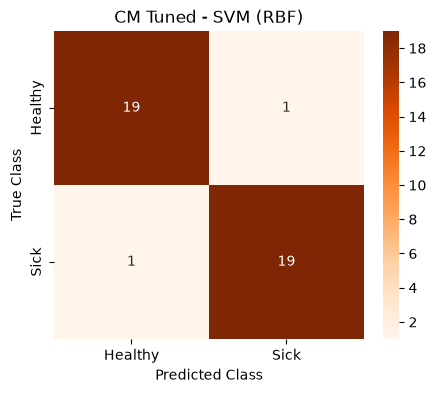

>>> Model SVM (RBF) Terbaik Berhasil Disimpan sebagai *_tuned.pkl! <<<

Memulai Hyperparameter Tuning untuk Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Kombinasi Parameter Terbaik: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Akurasi (Tuned): 0.9000
Macro F1-Score (Tuned): 0.8997

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.86      0.95      0.90        20
        Sick       0.94      0.85      0.89        20

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



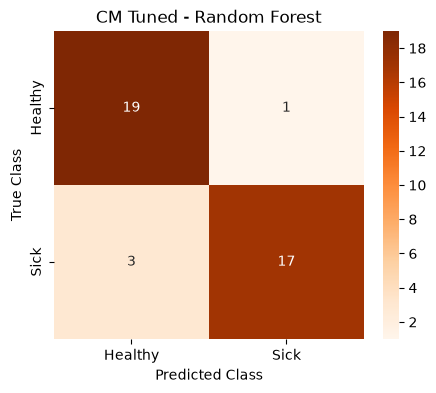


Memulai Hyperparameter Tuning untuk KNN...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Kombinasi Parameter Terbaik: {'n_neighbors': 5, 'weights': 'distance'}
Akurasi (Tuned): 0.8000
Macro F1-Score (Tuned): 0.8000

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.80      0.80      0.80        20
        Sick       0.80      0.80      0.80        20

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40



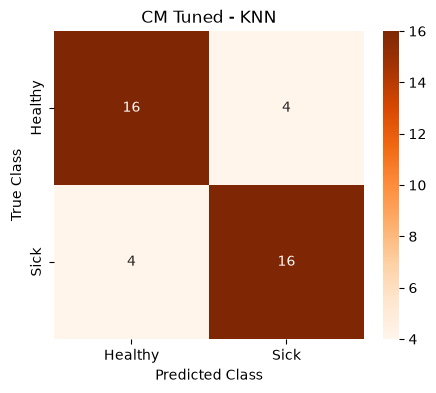

In [ ]:
# Sel 6: Eksekusi GridSearchCV dan Evaluasi
best_models = {}

for name, config in param_grids.items():
    print(f"\n{'='*40}")
    print(f"Memulai Hyperparameter Tuning untuk {name}...")
    
    # n_jobs=-1 menggunakan seluruh thread CPU untuk mempercepat proses
    grid_search = GridSearchCV(
        estimator=config['model'], 
        param_grid=config['params'], 
        cv=5, 
        scoring='f1_macro', 
        n_jobs=-1, 
        verbose=1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    print(f"Kombinasi Parameter Terbaik: {grid_search.best_params_}")
    
    # Prediksi menggunakan model terbaik hasil tuning
    y_pred = best_model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    
    print(f"Akurasi (Tuned): {acc:.4f}")
    print(f"Macro F1-Score (Tuned): {macro_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Healthy', 'Sick']))
    
    # Visualisasi Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=['Healthy', 'Sick'], yticklabels=['Healthy', 'Sick'])
    plt.title(f'CM Tuned - {name}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()
    
    # Simpan model SVM yang sudah dioptimasi
    if name == "SVM (RBF)":
        joblib.dump(best_model, '../models/svm_model_tuned.pkl')
        joblib.dump(scaler, '../models/scaler_tuned.pkl')
        feature_extractor.save('../models/efficientnet_extractor_tuned.keras')
        print(f">>> Model {name} Terbaik Berhasil Disimpan sebagai *_tuned.pkl! <<<")